In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Why employees leave: Predicting attrition and understanding tenure - a cross industry perspective

## Section 1 - Problem Formulation, Hypotheses and Literature Review
### Why this topic

I chose employee attrition as my project topic because it builds on my experience in workforce planning and talent attraction where understanding employee turnover is essential for maintaining a stable and effective workforce while also allowing me to further develop my data analysis skills and apply them to real world data.

Employee attrition is an important topic in workforce management as understanding and managing why employees leave is essential for organizations of all sizes and industries. It is not only and HR issue but also a data problem: when employees leave, what factors influence this decision and how these patterns can be identified and measured. 

The financial cost is real and large. Estimates of replacement cost vary by methodology —
Glassdoor (2024) puts the figure at 33% of annual salary, while SHRM (2022) estimates
between 50% and 200% depending on seniority and role. For a company of 1,000 employees with an average salary of 60 000 USD and an attrition rate of 15%, that means 150 departures per year. Even at the conservative Glassdoor estimate of 33%, the replacement cost alone reaches 2.97M USD annually before accounting for lost knowledge, reduced team morale and the time it takes a new hire to 
reach full productivity.

But the cost goes beyond the numbers. When experienced employees leave they take knowledge and know-how, client relationships and team continuity with them. The remaining employees absorb extra workload, morale drops, and the employer brand weakens in the talent market - making the next round of hiring harder and more
expensive. This is why attrition is a strategic issue not a routine HR metric.

Attrition rarely happens without warning. Research consistently shows it is preceded by identifiable signals: workload imbalance and overtime, inadequate compensation, limited career growth, poor manager relationships,  and lack of recognition. These are not just qualitative impressions - they are measurable variables, and that is exactly what makes attrition one of the few HR topics where data analysis can produce a direct, actionable business impact.

## References

[Indeed (2025). *16 Reasons Why Employees Choose To Leave Their Jobs.*](https://www.indeed.com/career-advice/career-development/reasons-employees-leave)

[Glassdoor (2024). *10 Reasons Employees Resign.*](https://www.glassdoor.com/blog/10-reasons-employees-resign/)

[BambooHR (2024). *Top Reasons Why Employees Leave Their Jobs.*](https://www.bamboohr.com/blog/top-reasons-why-employees-leave-their-jobs)

[DDI (2024). *Why Good Employees Leave.*](https://www.ddi.com/blog/why-good-employees-leave)

[SHRM (2024). *Future of Talent Retention: Why Employees Leave.*](https://www.shrm.org/executive-network/insights/future-of-talent-retention-report-why-employees-leave)

### 1.2 Dataset Strategy: Why Two Sources and How They Work Together

Finding two genuinely independent HR datasets is harder than it sounds. Several options were considered and rejected before arriving at the final choice:

- **Option A** (two datasets from one real location) — does not exist publicly. HR data is anonymized under GDPR.
- **Option B** (HR Attrition dataset + a European dataset) — no public EU/UK individual-level HR dataset exists. The Stack Overflow Survey covers many countries but cannot be split into two independent subsets since it uses one sampling method, one questionnaire, and one collection period.
- **Option C** (two real datasets: Babushkin Russia + India IT) — both are real, same industry, different location, but share only 5 overlapping columns. Too limited for meaningful comparison.
- **Option D** (Eurostat / Bulgarian labor agency) — Eurostat microdata requires accredited researcher access. Bulgarian NSI publishes only aggregate tables.

The chosen solution is the **HR Employee Attrition & Performance dataset** (Kaggle, IBM Watson Analytics) combined with the **Stack Overflow Developer Survey 2025**, using what I call Logic 2: enrichment from a different angle. There are three ways two datasets can relate to each other. They can replicate the same things in different contexts (Logic 1), each contribute a different angle on the same question (Logic 2) or operate at different levels of analysis - individual vs. organizational (Logic 3).

The two datasets are not merged directly. They operate at different levels and answer different questions.
By using Logic 2 each dataset contributes a different angle — individual level predictors from a synthetic company and market level context from 49 000+ real tech workers.

Both datasets are publicly available and are not included in this repository:
- HR Employee Attrition & Performance dataset: [Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)
- Stack Overflow Developer Survey 2025: [survey.stackoverflow](https://survey.stackoverflow.co/2025)

The HR Attrition dataset is the primary source I used to build and test predictive models. The Stack Overflow Survey provides an external reference point: if the patterns found in a synthetic dataset appear in real world data as well the conclusions carry more weight.

The datasets are not equivalent and are not treated as such. They are two independent perspectives on the same phenomenon.


### 1.3 What We Already Know

Research on why employees leave consistently points to the same core drivers, regardless of industry or methodology. 
From an employee perspective the most commonly cited reasons for leaving are lack of growth, inadequate compensation, feeling undervalued, poor management relationships, and limited career advancement (Indeed, 2025; SHRM, 2024).

In predictive models however, the strongest measurable signals are often different - not because employees name these directly, but because they are measurable indicators that represent the underlying factors mentioned above:

1. **Overtime** — an indicator of workload imbalance and burnout
2. **Monthly compensation** — the effect is nonlinear and interacts with job level
3. **Job and environment satisfaction** — captures recognition and engagement in one measurable signal
4. **Years at company** — early tenure employees (0–3 years) show the highest risk, often linked to unmet growth expectations (DDI, 2024)
5. **Distance from home** — in traditional office settings, a measure of work-life balance; in the recent years context it is closely tied to expectations around remote work and flexible working setup. As hybrid and remote work became the norm in tech, physical distance from the office became less about commute and more about whether employees have autonomy over where and how they work.

Manager quality sits across several of these factors simultaneously. Indeed identifies both "seeking a better management relationship" and "needing more feedback or structure" as independent reasons for leaving - suggesting the manager effect operates through multiple channels, not just one. This directly motivates H6 in this project.

On the tenure side, prior research shows that the risk of leaving is not constant over time and it tends to be highest in the first 12–18 months, drops during mid-tenure, and rises again around 4–6 years. Manager quality has a measurable effect on how quickly people leave.

The Stack Overflow Developer Survey 2025 adds a real-world data point. With 49,000+ respondents from 177 countries, it captures job satisfaction, compensation, remote work preferences, and active job seeking behavior providing industry-level context that the HR Attrition dataset cannot offer.


### 1.4 Dataset Limitations

Both datasets have real limitations. The biggest limitation is the synthetic nature of the HR Attrition dataset. The findings cannot be generalized to real organizations. The Stack Overflow Survey partially addresses this as it lets me check the direction of effects against a real population but it does not resolve the causality problem. Neither dataset tells me why people left only that they did or that they were looking.

**HR Attrition dataset**
- Synthetic data — not collected from a real organization
- One fictional company — findings cannot be generalized
- Attrition label is binary Yes/No, mechanism unknown
- Class imbalance: 16% Yes / 84% No — requires balancing
- Collected at one point in time — changes over time are not captured

**Stack Overflow Survey 2025**
- Self-reported — subject to response bias
- Sample skewed toward young, Western, English-speaking developers
- No direct attrition label - job seeking used instead
- Single point in time, no way to track how attitudes change over time

### 1.5 Research Questions and Hypothesis

This project investigates two related questions:

**Q1.1: Which factors predict whether an employee will leave?**

**Q1.2: How long do employees stay before leaving and does this differ by role, seniority level or manager relationship?**

These are different questions that require different analytical methods described in detail below.

All hypotheses are associative - they test whether a relationship exists between two variables not whether one causes the other. Causality cannot be established from observational data.


#### Group 1.1 — Factors predicting attrition (HR Attrition dataset)

**H1 — Overtime and job satisfaction as combined predictors of attrition**

H₀: The effect of overtime on attrition does not differ across job satisfaction levels.
H₁: Overtime has a significantly stronger effect on attrition among employees with low job satisfaction and the two factors interact rather than act independently.
*Planned method: logistic regression with interaction term
OverTime × JobSatisfaction; chi-square as a preliminary check*

**H2 — Compensation and seniority level as combined predictors of attrition**

H₀: The relationship between monthly income and attrition is the same across all job levels.
H₁: The attrition risk associated with lower income is significantly stronger at higher job levels. Senior employees who are underpaid relative to their role show higher attrition than junior employees at the same absolute salary.
*Planned method: logistic regression with interaction term
MonthlyIncome × JobLevel*

**H3 — Work environment satisfaction vs. job satisfaction**

H₀: Job satisfaction and work environment satisfaction contribute equally to predicting attrition.
H₁: Environment satisfaction is a stronger independent predictor of attrition than job satisfaction.
*Planned method: multiple logistic regression with standardized coefficients; t-test as a preliminary check*

**H4 — Remote work and attrition intent**

H₀: There is no significant difference in attrition intent between employees with access to remote or hybrid work and those required to work fully on site.
H₁: Lack of remote work flexibility is associated with higher attrition intent, independently of compensation level.
*Planned method: chi-square test on SO dataset
(RemoteWork × AttritionIntent where AttritionIntent is derived from NewRole)*


#### Group 1.2 — Tenure analysis (HR Attrition dataset)

**H5 — Length of service differs by job role and seniority**

H₀: Tenure does not differ significantly across job roles.
H₁: Tenure differs significantly across job roles.
*Planned method: ANOVA + Tukey HSD as a preliminary test;
Kaplan-Meier survival curves as the main analysis if data permits*

**H5b — Attrition risk is highest at entry level and non linear across seniority**

H₀: Attrition rate does not differ significantly across job level groups.
H₁: Attrition rate differs significantly across job level groups.
*Planned method: chi-square test across JobLevel groups*

**H6 — Manager continuity as a stabilizing factor**

H₀: The length of time working with the same manager is not associated with attrition risk.
H₁: Employees who have worked with the same manager for longer show lower attrition risk independently of job satisfaction.
*Planned method: t-test as a preliminary check;
Cox Proportional Hazards if assumptions are met*


#### Cross-dataset validation (HR Attrition dataset + Stack Overflow Survey 2025)

**H7 — Compensation and satisfaction patterns generalize to real tech workers**

H₀: The compensation and satisfaction patterns found in the HR Attrition dataset do not appear in a real tech population.
H₁: Dissatisfaction with compensation and lack of growth opportunities are expected to appear as significant drivers of attrition intent in the Stack Overflow Survey 2025, mirroring the patterns tested in H2 and H3.
*Planned method: analysis of AttritionIntent × ConvertedCompYearly
and AttritionIntent × JobSat in the SO dataset*

**H8 — Individual contributors show higher mobility than people managers**

H₀: Attrition intent does not differ significantly between individual contributors and people managers in tech.
H₁: Individual contributors show higher attrition intent than people managers suggesting career growth limitations are stronger for technical tracks than for management tracks.
*Planned method: chi-square test on AttritionIntent × ICorPM in SO dataset*

## Section 2 - Data Loading
### Loading the datasets
Both datasets are loaded locally. They are not included in the repository. See section 1.2 for download links.

In [16]:
hr_data = pd.read_csv("data/kaggle-attrition/attrition.csv")
so_data = pd.read_csv("data/stack-overflow-developer-survey-2025/survey_results_public.csv",
                        low_memory = False)
                      
print("HR Attrition dataset:", hr_data.shape)
print("Stack Overflow Survey:", so_data.shape)                     

HR Attrition dataset: (1470, 35)
Stack Overflow Survey: (49191, 172)


### HR Attrition dataset

In [17]:
print("HR Attrition Dataset")
print(f"Rows: {hr_data.shape[0]}, Columns: {hr_data.shape[1]}")
print(f"\nMissing values: {hr_data.isnull().sum().sum()}")
print(f"\nData types:\n{hr_data.dtypes.value_counts()}")
print(f"\nAttrition distribution:\n{hr_data['Attrition'].value_counts()}")
print(f"\nAttrition rate: {hr_data['Attrition'].value_counts(normalize=True).round(3)}")

HR Attrition Dataset
Rows: 1470, Columns: 35

Missing values: 0

Data types:
int64     26
object     9
Name: count, dtype: int64

Attrition distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64


The dataset has no missing values — expected for synthetic data. 
The attrition rate is 16.1% (237 out of 1,470 employees) which confirms the class imbalance documented in Section 1.4.

The columns which carry no analytical value are removed before analysis:
- EmployeeCount and StandardHours (constants across all rows)
- Over18 (all employees are over 18)
- EmployeeNumber (a row identifier, not a predictor)
- DailyRate and HourlyRate (we use MonthlyIncome)

In [18]:
cols_to_remove = ['EmployeeCount', 'StandardHours', 'Over18',
                'EmployeeNumber', 'DailyRate', 'HourlyRate']

hr_data = hr_data.drop(columns=cols_to_remove, errors='ignore')
print(f"Remaining columns: {hr_data.shape[1]}")
print(hr_data.columns.tolist())

Remaining columns: 29
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [19]:
# Attrition is stored as a string "Yes"/"No" and needs to be converted to binary (0/1) for use in statistical models

hr_data['Attrition_binary'] = (hr_data['Attrition'] == 'Yes').astype(int)
print(hr_data['Attrition_binary'].value_counts())

Attrition_binary
0    1233
1     237
Name: count, dtype: int64


In [20]:
hr_data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_binary
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,...,4,1,6,3,3,2,2,2,2,0


In [21]:
hr_data.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_binary
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,...,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,0.161224
std,9.135373,8.106864,1.024165,1.093082,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,...,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,0.367863
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,...,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,0.000000
50%,36.000000,7.000000,3.000000,3.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,...,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,0.000000
75%,43.000000,14.000000,4.000000,4.000000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,...,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,0.000000
max,60.000000,29.000000,5.000000,4.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,...,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,1.000000


The `describe()` output shows the ranges of all numerical columns. 
A few things to note:
- MonthlyIncome ranges from 1 009 to 19 999 - wide range, expected for a mixed seniority dataset
- Age ranges from 18 to 60 — no outliers
- YearsAtCompany max is 40, YearsWithCurrManager max is 17
- All satisfaction columns are within the expected 1–4 range

There are no obvious data entry errors or impossible values identified.

### 2.2 Scale definitions

Several columns use a 1–4 rating scale, following the original dataset documentation:

**1 = Low / Bad, 2 = Medium / Good, 3 = High / Better, 4 = Very High / Best**

This applies to: `JobSatisfaction`, `EnvironmentSatisfaction`, 
`RelationshipSatisfaction`, `WorkLifeBalance`, `JobInvolvement` 
and `PerformanceRating`.

### 2.3 Stack Overflow Developer Survey 2025

In [22]:
print(f"Rows: {so_data.shape[0]}, Columns: {so_data.shape[1]}")

relevant_cols = ['RemoteWork', 'NewRole', 'JobSat', 'ConvertedCompYearly', 'ICorPM']
print(f"\nMissing values in relevant columns:")
print(so_data[relevant_cols].isnull().sum())
print(f"\nUsable rows (all relevant cols filled): {so_data[relevant_cols].dropna().shape[0]}")

Rows: 49191, Columns: 172

Missing values in relevant columns:
RemoteWork             15411
NewRole                13664
JobSat                 22521
ConvertedCompYearly    25244
ICorPM                 15948
dtype: int64

Usable rows (all relevant cols filled): 17145


The Stack Overflow Survey contains 49 191 responses and 172 columns. Only the columns relevant to H4, H7 and H8 are used in this project. With all relevant columns filled 17,145 rows are available for analysis — 
sufficient for the planned statistical tests.

NewRole is recoded into a binary variable AttritionIntent for use in hypothesis testing:
- 0 = not considering a change
- 1 = considering or has already transitioned

In [23]:
so_data['AttritionIntent'] = so_data['NewRole'].map({
    'I have neither consider or transitioned into a new career or industry': 0,
    'I have somewhat considered changing my career and/or the industry I work in': 1,
    'I have strongly considered changing my career and/or the industry I work in': 1,
    'I have transitioned into a new career and/or industry voluntarily': 1,
    'I have transitioned into a new career and/or industry involuntarily': 1
})

print(so_data['AttritionIntent'].value_counts())
print(f"\nAttrition intent rate: {so_data['AttritionIntent'].value_counts(normalize=True).round(3)}")

AttritionIntent
1.0    19322
0.0    16205
Name: count, dtype: int64

Attrition intent rate: AttritionIntent
1.0    0.544
0.0    0.456
Name: proportion, dtype: float64


54% of respondents indicate some level of attrition intent. This is likely inflated by selection bias as people actively considering a job change are more motivated to complete a developer survey. This limits the generalizability of H4, H7 and H8 findings and is treated as an additional limitation of the SO dataset.

## Section 3 - Exploratory Data Analysis

EDA is performed before any formal hypothesis testing. The goal is to understand the distributions, spot patterns and identify potential relationships between variables and not to prove anything yet.
The analysis follows univariate -> bivariate -> multivariate structure.

### 3.1 Attrition distribution (univariate analysis)

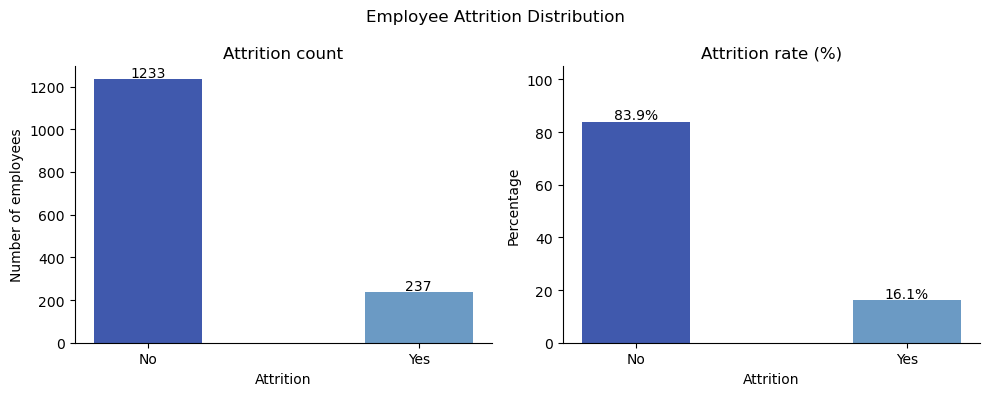

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#4059AD', '#6B9AC4']

# Left plot: counts
attrition_counts = hr_data['Attrition'].value_counts()
bars = axes[0].bar(attrition_counts.index, attrition_counts.values, color=colors, width = 0.4, align = 'center')
axes[0].set_title('Attrition count')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of employees')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha='center', fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right plot: percentages  
attrition_pct = hr_data['Attrition'].value_counts(normalize=True).mul(100)
bars2 = axes[1].bar(attrition_pct.index, attrition_pct.values, color=colors, width = 0.4, align = 'center')
axes[1].set_title('Attrition rate (%)')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Percentage')
axes[1].set_ylim(0, 105)

for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
        
plt.suptitle('Employee Attrition Distribution')
plt.tight_layout()
plt.show()

The dataset is imbalanced as 83.9% of employees stayed and 16.1% left. It is a positive business outcome but a challenge for modelling. A classifier that always predicts "No" would achieve 83.9% accuracy without learning anything meaningful. This class imbalance will be addressed in Section 4.

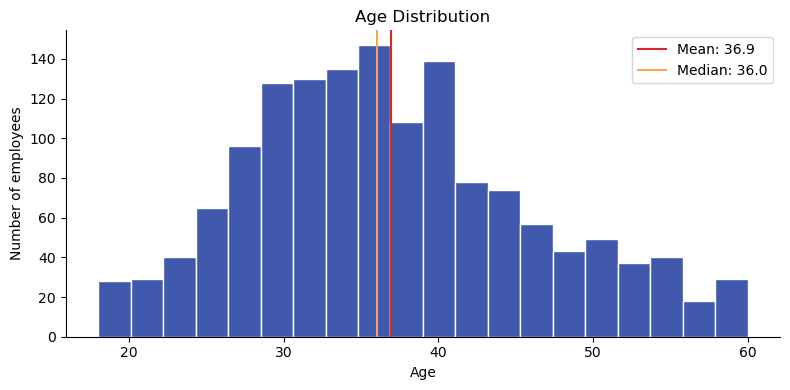

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(hr_data['Age'], bins=20, color='#4059AD', edgecolor='white')
ax.axvline(hr_data['Age'].mean(), color='#D62828', linestyle='-', label=f"Mean: {hr_data['Age'].mean():.1f}")
ax.axvline(hr_data['Age'].median(), color='#F2A65A', linestyle='-', label=f"Median: {hr_data['Age'].median():.1f}")
ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Number of employees')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()

The age distribution is approximately normal centered around 36-37 years. The workforce is predominantly mid career with relatively few employees under 25 or over 55.

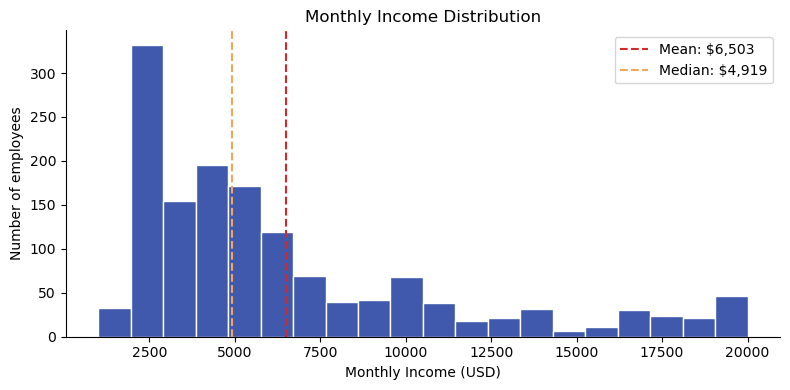

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(hr_data['MonthlyIncome'], bins=20, color='#4059AD', edgecolor='white')
ax.axvline(hr_data['MonthlyIncome'].mean(), color='#D62828', linestyle='--', label=f"Mean: ${hr_data['MonthlyIncome'].mean():,.0f}")
ax.axvline(hr_data['MonthlyIncome'].median(), color='#F2A65A', linestyle='--', label=f"Median: ${hr_data['MonthlyIncome'].median():,.0f}")

ax.set_title('Monthly Income Distribution')
ax.set_xlabel('Monthly Income (USD)')
ax.set_ylabel('Number of employees')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()

Monthly income is right skewed. The majority of employees earn between 2000 - 5000 USD with a long tail toward higher salaries. The mean ( 6503 USD) is significantly higher than the median (4919 USD) driven by a smaller group of high earners. This skiwness is relevant for H2 - the relationship betwee income and attrition may not be linear.

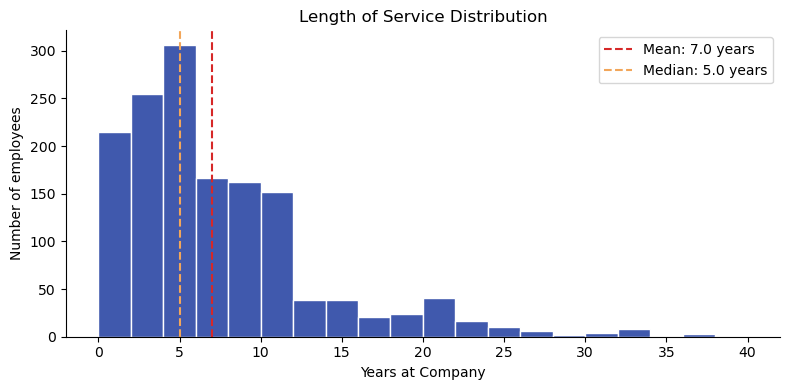

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(hr_data['YearsAtCompany'], bins=20, color='#4059AD', edgecolor='white')
ax.axvline(hr_data['YearsAtCompany'].mean(), color='#D62828', linestyle='--', label=f"Mean: {hr_data['YearsAtCompany'].mean():.1f} years")
ax.axvline(hr_data['YearsAtCompany'].median(), color='#F2A65A', linestyle='--', label=f"Median: {hr_data['YearsAtCompany'].median():.1f} years")

ax.set_title('Length of Service Distribution')
ax.set_xlabel('Years at Company')
ax.set_ylabel('Number of employees')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()

Length of service is strongly right skewed. Most employees have fewer than 10 years at the company where the median is 5 years. The long tail suggests a stable core of long term employees combined with high early-stage turnover. This pattern is consistent with H5 (attrition risk is expected to be highest in the first few years of employment.

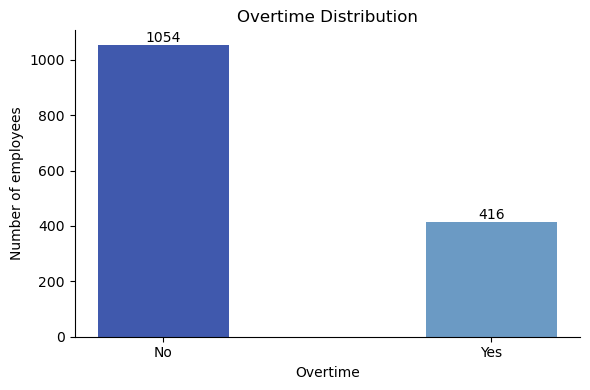

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))

overtime_counts = hr_data['OverTime'].value_counts()
bars = ax.bar(overtime_counts.index, overtime_counts.values, color=['#4059AD', '#6B9AC4'], width=0.4)

ax.set_title('Overtime Distribution')
ax.set_xlabel('Overtime')
ax.set_ylabel('Number of employees')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

28% of employees (416 out of 1470) work overtime. This is a significant proportion andd directly relevant to H1 - whether overtime combined with jow job satisfaction is a stronger predictor of attrition than either factor alone.